# NB14: ASMA PA Isolate Profiling & Pfam-Based Phylogenetic Tree

**Project**: CF Protective Microbiome Formulation Design
**Goal**: Profile every PROTECT PA isolate for virulence systems, then build
a Pfam domain-based phylogenetic tree placing PROTECT isolates alongside
PAO1, PA14, and sampled lung/airway PA from the pangenome.

## Why Pfam?
PROTECT genomes (in `protect_genomedepot`) and pangenome genomes (in
`kbase_ke_pangenome`) use different annotation pipelines, so gene names
don't match reliably. **Pfam domain IDs are standardized** across pipelines
(~3,200 domains per PA genome), providing a high-resolution, pipeline-independent
vocabulary for computing genome distances.

## Annotations on the tree
- **Ring 1**: ExoU/ExoS T3SS effector type (from gene name queries)
- **Ring 2**: Biofilm type — Pel+Psl vs Pel-only
- **Ring 3**: Isolation source — CF/Lung/Environmental/Reference
- **Ring 4**: Identity — ASMA (red) / PAO1 (navy) / PA14 (dark red) / Pangenome (grey)
- **Tip labels**: ASMA IDs and reference strain names

**Requires**: BERDL Spark + pycirclize

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, to_tree
from Bio import Phylo
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

from berdl_notebook_utils.setup_spark_session import get_spark_session
spark = get_spark_session()

GOLD = Path.home() / 'protect' / 'gold'
DATA = Path('/home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data')
FIGS = Path('/home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/figures')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

PA_CLADE = 's__Pseudomonas_aeruginosa--RS_GCF_001457615.1'
PAO1_ID = 'RS_GCF_000006765.1'
PA14_ID = 'RS_GCF_000014625.1'

print('Setup complete')

Setup complete


## 1. Per-ASMA Isolate Virulence Profiling

Query virulence genes from protect_genomedepot for all 651 PA genomes.
This provides the gene-name-based annotations for the tree.

In [2]:
# Virulence gene query
virulence_genes = ['exoU','exoS','exoT','exoY','pelA','pelB','pelC','pelD','pelE','pelF','pelG',
    'pslA','pslB','pslC','pslD','pslE','pslF','pslG','algD','algU','mucA','mucB',
    'ladS','retS','gacS','gacA','rsmA','lasR','lasI','rhlR','rhlI','pqsA','pqsR',
    'pvdA','pvdD','pchA','pchD']
gene_sql = "','".join(virulence_genes)

print(f'Querying {len(virulence_genes)} virulence genes...')
protect_vir = spark.sql(f"""
    SELECT bg.genome_id, bg.name AS gene_name
    FROM protect_genomedepot.browser_gene bg
    JOIN protect_genomedepot.browser_genome bge ON bg.genome_id = bge.id
    JOIN protect_genomedepot.browser_taxon bt ON bge.taxon_id = bt.id
    WHERE bt.name LIKE '%aeruginosa%'
      AND bg.name IN ('{gene_sql}')
""").toPandas()

# Build presence matrix
vir_pres = protect_vir.groupby(['genome_id','gene_name']).size().unstack(fill_value=0)
vir_pres = (vir_pres > 0).astype(int)
print(f'Virulence matrix: {vir_pres.shape[0]} genomes x {vir_pres.shape[1]} genes')

# Classify T3SS
def classify_t3ss(row):
    u = row.get('exoU', 0) > 0; s = row.get('exoS', 0) > 0
    if u and s: return 'ExoU+ExoS+'
    elif u: return 'ExoU+'
    elif s: return 'ExoS+'
    else: return 'Neither'

vir_pres['t3ss_type'] = vir_pres.apply(classify_t3ss, axis=1)

# Classify biofilm
pel_cols = [c for c in ['pelA','pelB','pelC','pelD','pelE','pelF','pelG'] if c in vir_pres.columns]
psl_cols = [c for c in ['pslA','pslB','pslC','pslD','pslE','pslF','pslG'] if c in vir_pres.columns]
vir_pres['pel_n'] = vir_pres[pel_cols].sum(axis=1) if pel_cols else 0
vir_pres['psl_n'] = vir_pres[psl_cols].sum(axis=1) if psl_cols else 0

def classify_bf(row):
    has_pel = row['pel_n'] >= 3; has_psl = row['psl_n'] >= 2
    if has_pel and has_psl: return 'Pel+Psl'
    elif has_pel: return 'Pel-only'
    elif has_psl: return 'Psl-only'
    else: return 'Minimal'

vir_pres['biofilm_type'] = vir_pres.apply(classify_bf, axis=1)

print(f'\nT3SS: {vir_pres.t3ss_type.value_counts().to_dict()}')
print(f'Biofilm: {vir_pres.biofilm_type.value_counts().to_dict()}')

# Map genome_id to ASMA ID
genome_to_asma = spark.sql("""
    SELECT bge.id AS genome_id, bge.name
    FROM protect_genomedepot.browser_genome bge
    JOIN protect_genomedepot.browser_taxon bt ON bge.taxon_id = bt.id
    WHERE bt.name LIKE '%aeruginosa%'
""").toPandas()
genome_to_asma['asma_id'] = genome_to_asma.name.str.extract(r'((?:ASMA|APA)[- ]?\d+)', expand=False)
genome_to_asma['asma_id'] = genome_to_asma.asma_id.str.replace(' ', '-')
gid_to_asma = genome_to_asma.set_index('genome_id')['asma_id'].to_dict()
print(f'Genome-to-ASMA mapping: {sum(1 for v in gid_to_asma.values() if v)}/{len(gid_to_asma)}')

Querying 37 virulence genes...


Virulence matrix: 643 genomes x 24 genes

T3SS: {'ExoS+': 304, 'Neither': 293, 'ExoU+': 46}
Biofilm: {'Pel-only': 640, 'Minimal': 3}


Genome-to-ASMA mapping: 651/651


## 2. Link to Strain Groups and Patient Status

In [3]:
# Load isolate and patient metadata
isolates = pd.read_parquet(GOLD / 'dim_isolate.snappy.parquet')
pa_iso = isolates[isolates.species == 'Pseudomonas aeruginosa'].copy()

# Map ASMA ID → strain group, representative status
asma_to_sg = pa_iso.set_index('asma_id')['strain_group'].to_dict()
asma_to_rep = pa_iso.set_index('asma_id')['representative'].to_dict()

# Get representative ASMA IDs (one per strain group)
reps = pa_iso[pa_iso.representative == 'Yes']
print(f'PA strain groups: {pa_iso.strain_group.nunique()}')
print(f'Representatives: {len(reps)}')

# Map protect_genomedepot genome_id → strain group
gid_to_sg = {}
gid_to_rep = {}
for gid, asma in gid_to_asma.items():
    if asma:
        gid_to_sg[gid] = asma_to_sg.get(asma, None)
        gid_to_rep[gid] = asma_to_rep.get(asma, 'No')

# Find the protect_genomedepot genome IDs for representatives
rep_gids = [gid for gid, r in gid_to_rep.items() if r == 'Yes']
print(f'Representative genome IDs found: {len(rep_gids)}')
for gid in rep_gids:
    asma = gid_to_asma.get(gid, '?')
    sg = gid_to_sg.get(gid, '?')
    t3ss = vir_pres.loc[gid, 't3ss_type'] if gid in vir_pres.index else '?'
    print(f'  {asma} (sg={sg}): {t3ss}')

PA strain groups: 15
Representatives: 15
Representative genome IDs found: 15
  ASMA-20 (sg=725.0): Neither
  ASMA-169 (sg=721.0): ExoS+
  ASMA-513 (sg=729.0): Neither
  ASMA-636 (sg=599.0): ExoS+
  ASMA-1144 (sg=690.0): ExoS+
  ASMA-1320 (sg=708.0): ExoU+
  ASMA-1642 (sg=667.0): ExoU+
  ASMA-1804 (sg=615.0): ExoS+
  ASMA-2068 (sg=724.0): ExoS+
  ASMA-2356 (sg=713.0): ExoS+
  ASMA-2364 (sg=710.0): ExoS+
  ASMA-2890 (sg=583.0): ExoS+
  ASMA-3072 (sg=620.0): ExoS+
  ASMA-4151 (sg=702.0): ExoS+
  ASMA-4963 (sg=627.0): ?


## 3. Build Pfam Domain Profiles

### 3a. PROTECT PA representatives — from protect_genomedepot
### 3b. Pangenome lung PA + references — from eggnog_mapper_annotations

In [4]:
# 3a: PROTECT Pfam profiles (15 reps)
print('Querying Pfam domains for PROTECT PA representatives...')
rep_gid_sql = ','.join(str(g) for g in rep_gids)

protect_pfam = spark.sql(f"""
    SELECT bg.genome_id, ba.value AS pfam_domain
    FROM protect_genomedepot.browser_annotation ba
    JOIN protect_genomedepot.browser_gene bg ON ba.gene_id_id = bg.id
    WHERE ba.source = 'Pfam database'
      AND bg.genome_id IN ({rep_gid_sql})
""").toPandas()

print(f'PROTECT Pfam hits: {len(protect_pfam)} rows, {protect_pfam.genome_id.nunique()} genomes')

# Build per-genome Pfam presence
protect_pfam_pres = protect_pfam.groupby(['genome_id','pfam_domain']).size().unstack(fill_value=0)
protect_pfam_pres = (protect_pfam_pres > 0).astype(int)
# Use ASMA ID as index label
protect_pfam_pres.index = [f'PROTECT_{gid_to_asma.get(gid, gid)}' for gid in protect_pfam_pres.index]
print(f'PROTECT Pfam matrix: {protect_pfam_pres.shape}')

Querying Pfam domains for PROTECT PA representatives...


PROTECT Pfam hits: 130582 rows, 13 genomes
PROTECT Pfam matrix: (13, 3813)


In [5]:
# 3b: Pangenome lung PA + reference Pfam profiles
# Sample ~150 lung/airway PA from pangenome
pa_env = pd.read_csv(DATA / 'pa_genome_sources.tsv', sep='\t')
lung_pa = pa_env[pa_env.category.isin(['CF patient', 'Lung/Respiratory'])]
np.random.seed(42)
n_sample = min(150, len(lung_pa))
sampled_ids = lung_pa.sample(n_sample, random_state=42).genome_id.tolist()

# Add references
pan_ids = list(set(sampled_ids + [PAO1_ID, PA14_ID]))
pan_id_sql = "','".join(pan_ids)

print(f'Querying Pfam for {len(pan_ids)} pangenome genomes...')

# Get gene clusters → genomes mapping
pan_gc = spark.sql(f"""
    SELECT g.genome_id, ggj.gene_cluster_id
    FROM kbase_ke_pangenome.gene g
    JOIN kbase_ke_pangenome.gene_genecluster_junction ggj ON g.gene_id = ggj.gene_id
    WHERE g.genome_id IN ('{pan_id_sql}')
""").toPandas()

print(f'Gene-cluster mappings: {len(pan_gc)} rows, {pan_gc.genome_id.nunique()} genomes')

# Get Pfam annotations for these gene clusters
gc_ids = pan_gc.gene_cluster_id.unique()
print(f'Querying Pfam for {len(gc_ids)} gene clusters...')

# Batch query
all_pfam = []
batch_sz = 5000
for i in range(0, len(gc_ids), batch_sz):
    batch = gc_ids[i:i+batch_sz]
    batch_sql = "','".join(batch)
    df = spark.sql(f"""
        SELECT ea.query_name AS gene_cluster_id, ea.PFAMs
        FROM kbase_ke_pangenome.eggnog_mapper_annotations ea
        WHERE ea.query_name IN ('{batch_sql}')
          AND ea.PFAMs IS NOT NULL AND ea.PFAMs != '' AND ea.PFAMs != '-'
    """).toPandas()
    all_pfam.append(df)
    if i % 20000 == 0:
        print(f'  Batch {i//batch_sz+1}/{(len(gc_ids)-1)//batch_sz+1}...')

pan_pfam = pd.concat(all_pfam, ignore_index=True)
print(f'Pangenome Pfam: {len(pan_pfam)} gene cluster annotations')

# Explode comma-separated Pfam domains
pan_pfam_exploded = pan_pfam.assign(
    pfam_domain=pan_pfam.PFAMs.str.split(',')
).explode('pfam_domain')

# Join with genome mapping
pan_genome_pfam = pan_gc.merge(pan_pfam_exploded[['gene_cluster_id','pfam_domain']], on='gene_cluster_id')
print(f'Genome-Pfam mappings: {len(pan_genome_pfam)} rows')

# Build presence matrix
pan_pfam_pres = pan_genome_pfam.groupby(['genome_id','pfam_domain']).size().unstack(fill_value=0)
pan_pfam_pres = (pan_pfam_pres > 0).astype(int)
# Label references
pan_pfam_pres.index = [
    'REF_PAO1' if gid == PAO1_ID else 'REF_PA14' if gid == PA14_ID else f'PAN_{gid}'
    for gid in pan_pfam_pres.index
]
print(f'Pangenome Pfam matrix: {pan_pfam_pres.shape}')

Querying Pfam for 152 pangenome genomes...


Gene-cluster mappings: 931543 rows, 152 genomes
Querying Pfam for 33942 gene clusters...


  Batch 1/7...


  Batch 5/7...


Pangenome Pfam: 17149 gene cluster annotations


Genome-Pfam mappings: 1229794 rows
Pangenome Pfam matrix: (152, 3688)


In [6]:
# Merge PROTECT and pangenome Pfam matrices on shared domains
all_domains = sorted(set(protect_pfam_pres.columns) | set(pan_pfam_pres.columns))
print(f'Total unique Pfam domains: {len(all_domains)}')
print(f'  PROTECT-only: {len(set(protect_pfam_pres.columns) - set(pan_pfam_pres.columns))}')
print(f'  Pangenome-only: {len(set(pan_pfam_pres.columns) - set(protect_pfam_pres.columns))}')
print(f'  Shared: {len(set(protect_pfam_pres.columns) & set(pan_pfam_pres.columns))}')

# Reindex both to full domain set
protect_full = protect_pfam_pres.reindex(columns=all_domains, fill_value=0)
pan_full = pan_pfam_pres.reindex(columns=all_domains, fill_value=0)

# Concatenate
combined_pfam = pd.concat([protect_full, pan_full])
print(f'\nCombined Pfam matrix: {combined_pfam.shape[0]} genomes x {combined_pfam.shape[1]} domains')

# Filter to variable domains (present in 5-95% of genomes)
freq = combined_pfam.mean(axis=0)
variable = (freq > 0.05) & (freq < 0.95)
pfam_variable = combined_pfam.loc[:, variable]
print(f'Variable Pfam domains (5-95%): {pfam_variable.shape[1]}')

Total unique Pfam domains: 4651
  PROTECT-only: 963
  Pangenome-only: 838
  Shared: 2850

Combined Pfam matrix: 165 genomes x 4651 domains


Variable Pfam domains (5-95%): 1557


## 4. Pfam-Based Phylogenetic Tree

In [7]:
# Compute Jaccard distance and build UPGMA tree
print('Computing Jaccard distances...')
dist = pdist(pfam_variable.values, metric='jaccard')
print(f'Distance matrix: mean={dist.mean():.3f}, range=[{dist.min():.3f}, {dist.max():.3f}]')

print('Building UPGMA tree...')
Z = linkage(dist, method='average')

# Convert to Newick
def linkage_to_newick(Z, labels):
    tree_root = to_tree(Z, rd=False)
    def build(node, labels):
        if node.is_leaf():
            return f'{labels[node.id]}:{node.dist:.6f}'
        return f'({build(node.get_left(), labels)},{build(node.get_right(), labels)}):{node.dist:.6f}'
    return build(tree_root, labels) + ';'

labels = pfam_variable.index.tolist()
newick = linkage_to_newick(Z, labels)
tree = Phylo.read(StringIO(newick), 'newick')
print(f'Tree: {tree.count_terminals()} leaves')

with open(DATA / 'pa_pfam_tree.nwk', 'w') as f:
    f.write(newick)
print('Saved: pa_pfam_tree.nwk')

Computing Jaccard distances...
Distance matrix: mean=0.415, range=[0.000, 0.972]
Building UPGMA tree...
Tree: 165 leaves
Saved: pa_pfam_tree.nwk


## 5. Build Annotation Table

Combine virulence typing, patient metadata, and source classification
for all tree leaves.

In [8]:
# Build annotation dataframe for every leaf
leaf_names = [l.name for l in tree.get_terminals()]
annot = pd.DataFrame(index=leaf_names)

# Source / identity
def get_source(name):
    if name == 'REF_PAO1': return 'Reference'
    if name == 'REF_PA14': return 'Reference'
    if name.startswith('PROTECT_'): return 'PROTECT (CF)'
    # Pangenome
    gid = name.replace('PAN_', '')
    cat = pa_env.set_index('genome_id').get('category', pd.Series(dtype=str)).get(gid, 'Unknown')
    return cat

annot['source'] = [get_source(n) for n in leaf_names]

# Identity type
def get_identity(name):
    if name == 'REF_PAO1': return 'PAO1'
    if name == 'REF_PA14': return 'PA14'
    if name.startswith('PROTECT_'): return 'ASMA'
    return 'Pangenome'

annot['identity'] = [get_identity(n) for n in leaf_names]

# T3SS type
vir_nb13 = pd.read_csv(DATA / 'pa_virulence_systems.tsv', sep='\t', index_col=0)

def get_t3ss(name):
    if name == 'REF_PAO1': return 'ExoS+'
    if name == 'REF_PA14': return 'ExoU+'
    if name.startswith('PROTECT_'):
        # Look up in vir_pres by genome_id
        asma = name.replace('PROTECT_', '')
        # Find genome_id for this ASMA
        for gid, a in gid_to_asma.items():
            if a == asma and gid in vir_pres.index:
                return vir_pres.loc[gid, 't3ss_type']
        return 'Unknown'
    # Pangenome
    gid = name.replace('PAN_', '')
    return vir_nb13.get('t3ss_type', pd.Series(dtype=str)).get(gid, 'Unknown')

annot['t3ss_type'] = [get_t3ss(n) for n in leaf_names]

# Biofilm type
def get_biofilm(name):
    if name == 'REF_PAO1': return 'Pel+Psl'
    if name == 'REF_PA14': return 'Pel-only'
    if name.startswith('PROTECT_'):
        asma = name.replace('PROTECT_', '')
        for gid, a in gid_to_asma.items():
            if a == asma and gid in vir_pres.index:
                return vir_pres.loc[gid, 'biofilm_type']
        return 'Unknown'
    gid = name.replace('PAN_', '')
    return vir_nb13.get('biofilm_type', pd.Series(dtype=str)).get(gid, 'Unknown')

annot['biofilm_type'] = [get_biofilm(n) for n in leaf_names]

# Strain group (PROTECT only)
def get_sg(name):
    if not name.startswith('PROTECT_'): return ''
    asma = name.replace('PROTECT_', '')
    return str(asma_to_sg.get(asma, ''))

annot['strain_group'] = [get_sg(n) for n in leaf_names]

# Display label
def get_label(name):
    if name == 'REF_PAO1': return 'PAO1'
    if name == 'REF_PA14': return 'PA14'
    if name.startswith('PROTECT_'):
        asma = name.replace('PROTECT_', '')
        sg = asma_to_sg.get(asma, '?')
        return f'{asma} (sg{sg})'
    return ''

annot['label'] = [get_label(n) for n in leaf_names]

print(f'Annotations: {len(annot)} leaves')
print(f'\nIdentity: {annot.identity.value_counts().to_dict()}')
print(f'T3SS: {annot.t3ss_type.value_counts().to_dict()}')
print(f'Source: {annot.source.value_counts().to_dict()}')
print(f'\nPROTECT leaves:')
print(annot[annot.identity == 'ASMA'][['source','t3ss_type','biofilm_type','strain_group','label']].to_string())

Annotations: 165 leaves

Identity: {'Pangenome': 150, 'ASMA': 13, 'PA14': 1, 'PAO1': 1}
T3SS: {'ExoS+': 133, 'ExoU+': 29, 'Neither': 2, 'ExoU+ExoS+': 1}
Source: {'Lung/Respiratory': 128, 'CF patient': 22, 'PROTECT (CF)': 13, 'Reference': 2}

PROTECT leaves:
                         source t3ss_type biofilm_type strain_group                label
PROTECT_ASMA-1320  PROTECT (CF)     ExoU+     Pel-only        708.0  ASMA-1320 (sg708.0)
PROTECT_ASMA-513   PROTECT (CF)   Neither     Pel-only        729.0   ASMA-513 (sg729.0)
PROTECT_ASMA-636   PROTECT (CF)     ExoS+     Pel-only        599.0   ASMA-636 (sg599.0)
PROTECT_ASMA-2364  PROTECT (CF)     ExoS+     Pel-only        710.0  ASMA-2364 (sg710.0)
PROTECT_ASMA-2890  PROTECT (CF)     ExoS+     Pel-only        583.0  ASMA-2890 (sg583.0)
PROTECT_ASMA-169   PROTECT (CF)     ExoS+     Pel-only        721.0   ASMA-169 (sg721.0)
PROTECT_ASMA-2068  PROTECT (CF)     ExoS+     Pel-only        724.0  ASMA-2068 (sg724.0)
PROTECT_ASMA-3072  PROTECT (CF

## 6. Annotated Circular Tree

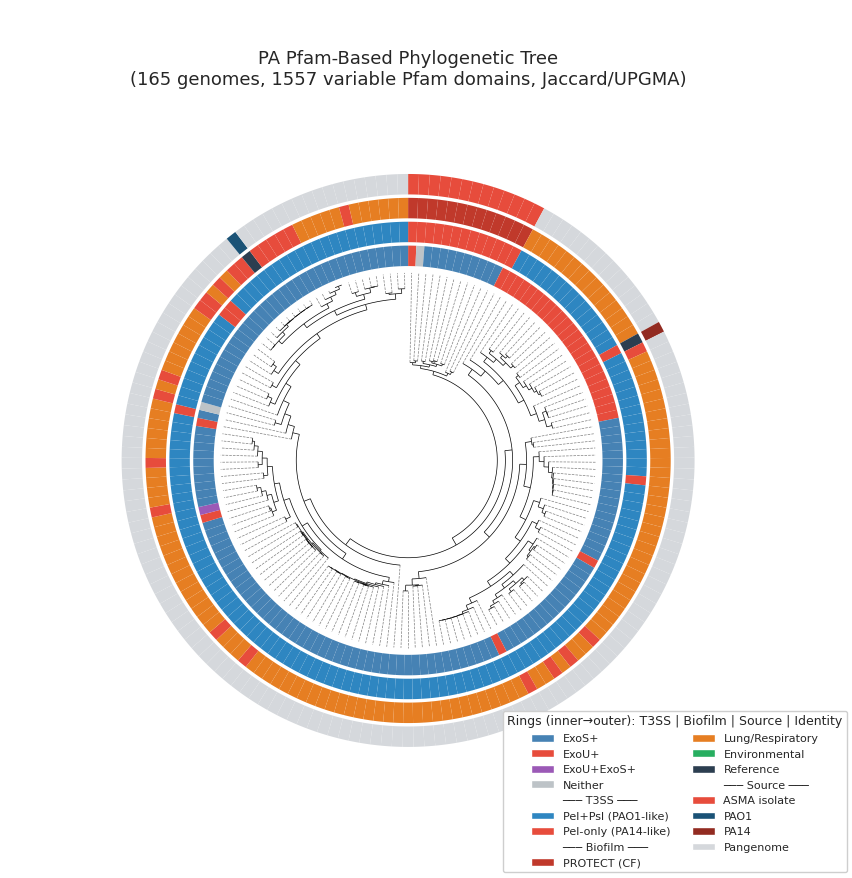

Saved: 14_pa_phylogenetic_tree.png


In [9]:
from pycirclize import Circos
from matplotlib.patches import Patch

# Color maps
t3ss_cm = {'ExoS+': '#4682B4', 'ExoU+': '#E74C3C', 'ExoU+ExoS+': '#9B59B6', 'Neither': '#BDC3C7', 'Unknown': '#F0F0F0'}
bf_cm = {'Pel+Psl': '#2E86C1', 'Pel+Psl+ (PAO1-like)': '#2E86C1', 'Pel-only': '#E74C3C',
         'Pel-only (PA14-like)': '#E74C3C', 'Psl-only': '#27AE60', 'Minimal': '#BDC3C7', 'Unknown': '#F0F0F0'}
src_cm = {'CF patient': '#E74C3C', 'Lung/Respiratory': '#E67E22', 'Upper Airway': '#F1C40F',
          'Other Clinical': '#3498DB', 'Environmental': '#27AE60', 'Other': '#BDC3C7',
          'Unknown': '#F0F0F0', 'Reference': '#2C3E50', 'PROTECT (CF)': '#C0392B'}
id_cm = {'ASMA': '#E74C3C', 'PAO1': '#1A5276', 'PA14': '#922B21', 'Pangenome': '#D5D8DC'}

# Build color arrays
ring_t3ss = [t3ss_cm.get(annot.loc[n, 't3ss_type'], '#F0F0F0') for n in leaf_names]
ring_bf = [bf_cm.get(annot.loc[n, 'biofilm_type'], '#F0F0F0') for n in leaf_names]
ring_src = [src_cm.get(annot.loc[n, 'source'], '#F0F0F0') for n in leaf_names]
ring_id = [id_cm.get(annot.loc[n, 'identity'], '#D5D8DC') for n in leaf_names]

# Build tree visualization
circos, tv = Circos.initialize_from_tree(
    tree, r_lim=(20, 55), leaf_label_size=0
)

sector = circos.sectors[0]

# Ring 1: T3SS (inner)
t1 = sector.add_track((57, 63))
for i, c in enumerate(ring_t3ss):
    t1.rect(i, i+1, fc=c, ec='none')

# Ring 2: Biofilm
t2 = sector.add_track((64, 70))
for i, c in enumerate(ring_bf):
    t2.rect(i, i+1, fc=c, ec='none')

# Ring 3: Source
t3 = sector.add_track((71, 77))
for i, c in enumerate(ring_src):
    t3.rect(i, i+1, fc=c, ec='none')

# Ring 4: Identity (ASMA / PAO1 / PA14 / Pangenome)
t4 = sector.add_track((78, 84))
for i, c in enumerate(ring_id):
    t4.rect(i, i+1, fc=c, ec='none')

# Labels are shown via colored identity ring — ASMA (red), PAO1 (navy), PA14 (dark red)
# Individual text labels omitted to avoid pycirclize text placement issues

fig = circos.plotfig()

# Legend
legend_elements = [
    Patch(fc='#4682B4', label='ExoS+'), Patch(fc='#E74C3C', label='ExoU+'),
    Patch(fc='#9B59B6', label='ExoU+ExoS+'), Patch(fc='#BDC3C7', label='Neither'),
    Patch(fc='white', ec='white', label='─── T3SS ───'),
    Patch(fc='#2E86C1', label='Pel+Psl (PAO1-like)'), Patch(fc='#E74C3C', label='Pel-only (PA14-like)'),
    Patch(fc='white', ec='white', label='─── Biofilm ───'),
    Patch(fc='#C0392B', label='PROTECT (CF)'), Patch(fc='#E67E22', label='Lung/Respiratory'),
    Patch(fc='#27AE60', label='Environmental'), Patch(fc='#2C3E50', label='Reference'),
    Patch(fc='white', ec='white', label='─── Source ───'),
    Patch(fc='#E74C3C', label='ASMA isolate'), Patch(fc='#1A5276', label='PAO1'),
    Patch(fc='#922B21', label='PA14'), Patch(fc='#D5D8DC', label='Pangenome'),
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=8, ncol=2,
           title='Rings (inner→outer): T3SS | Biofilm | Source | Identity',
           title_fontsize=9, framealpha=0.95)

plt.suptitle(f'PA Pfam-Based Phylogenetic Tree\n'
             f'({len(leaf_names)} genomes, {pfam_variable.shape[1]} variable Pfam domains, Jaccard/UPGMA)',
             fontsize=13, y=0.98)

plt.savefig(FIGS / '14_pa_phylogenetic_tree.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: 14_pa_phylogenetic_tree.png')

## 7. ASMA Virulence Profile Summary

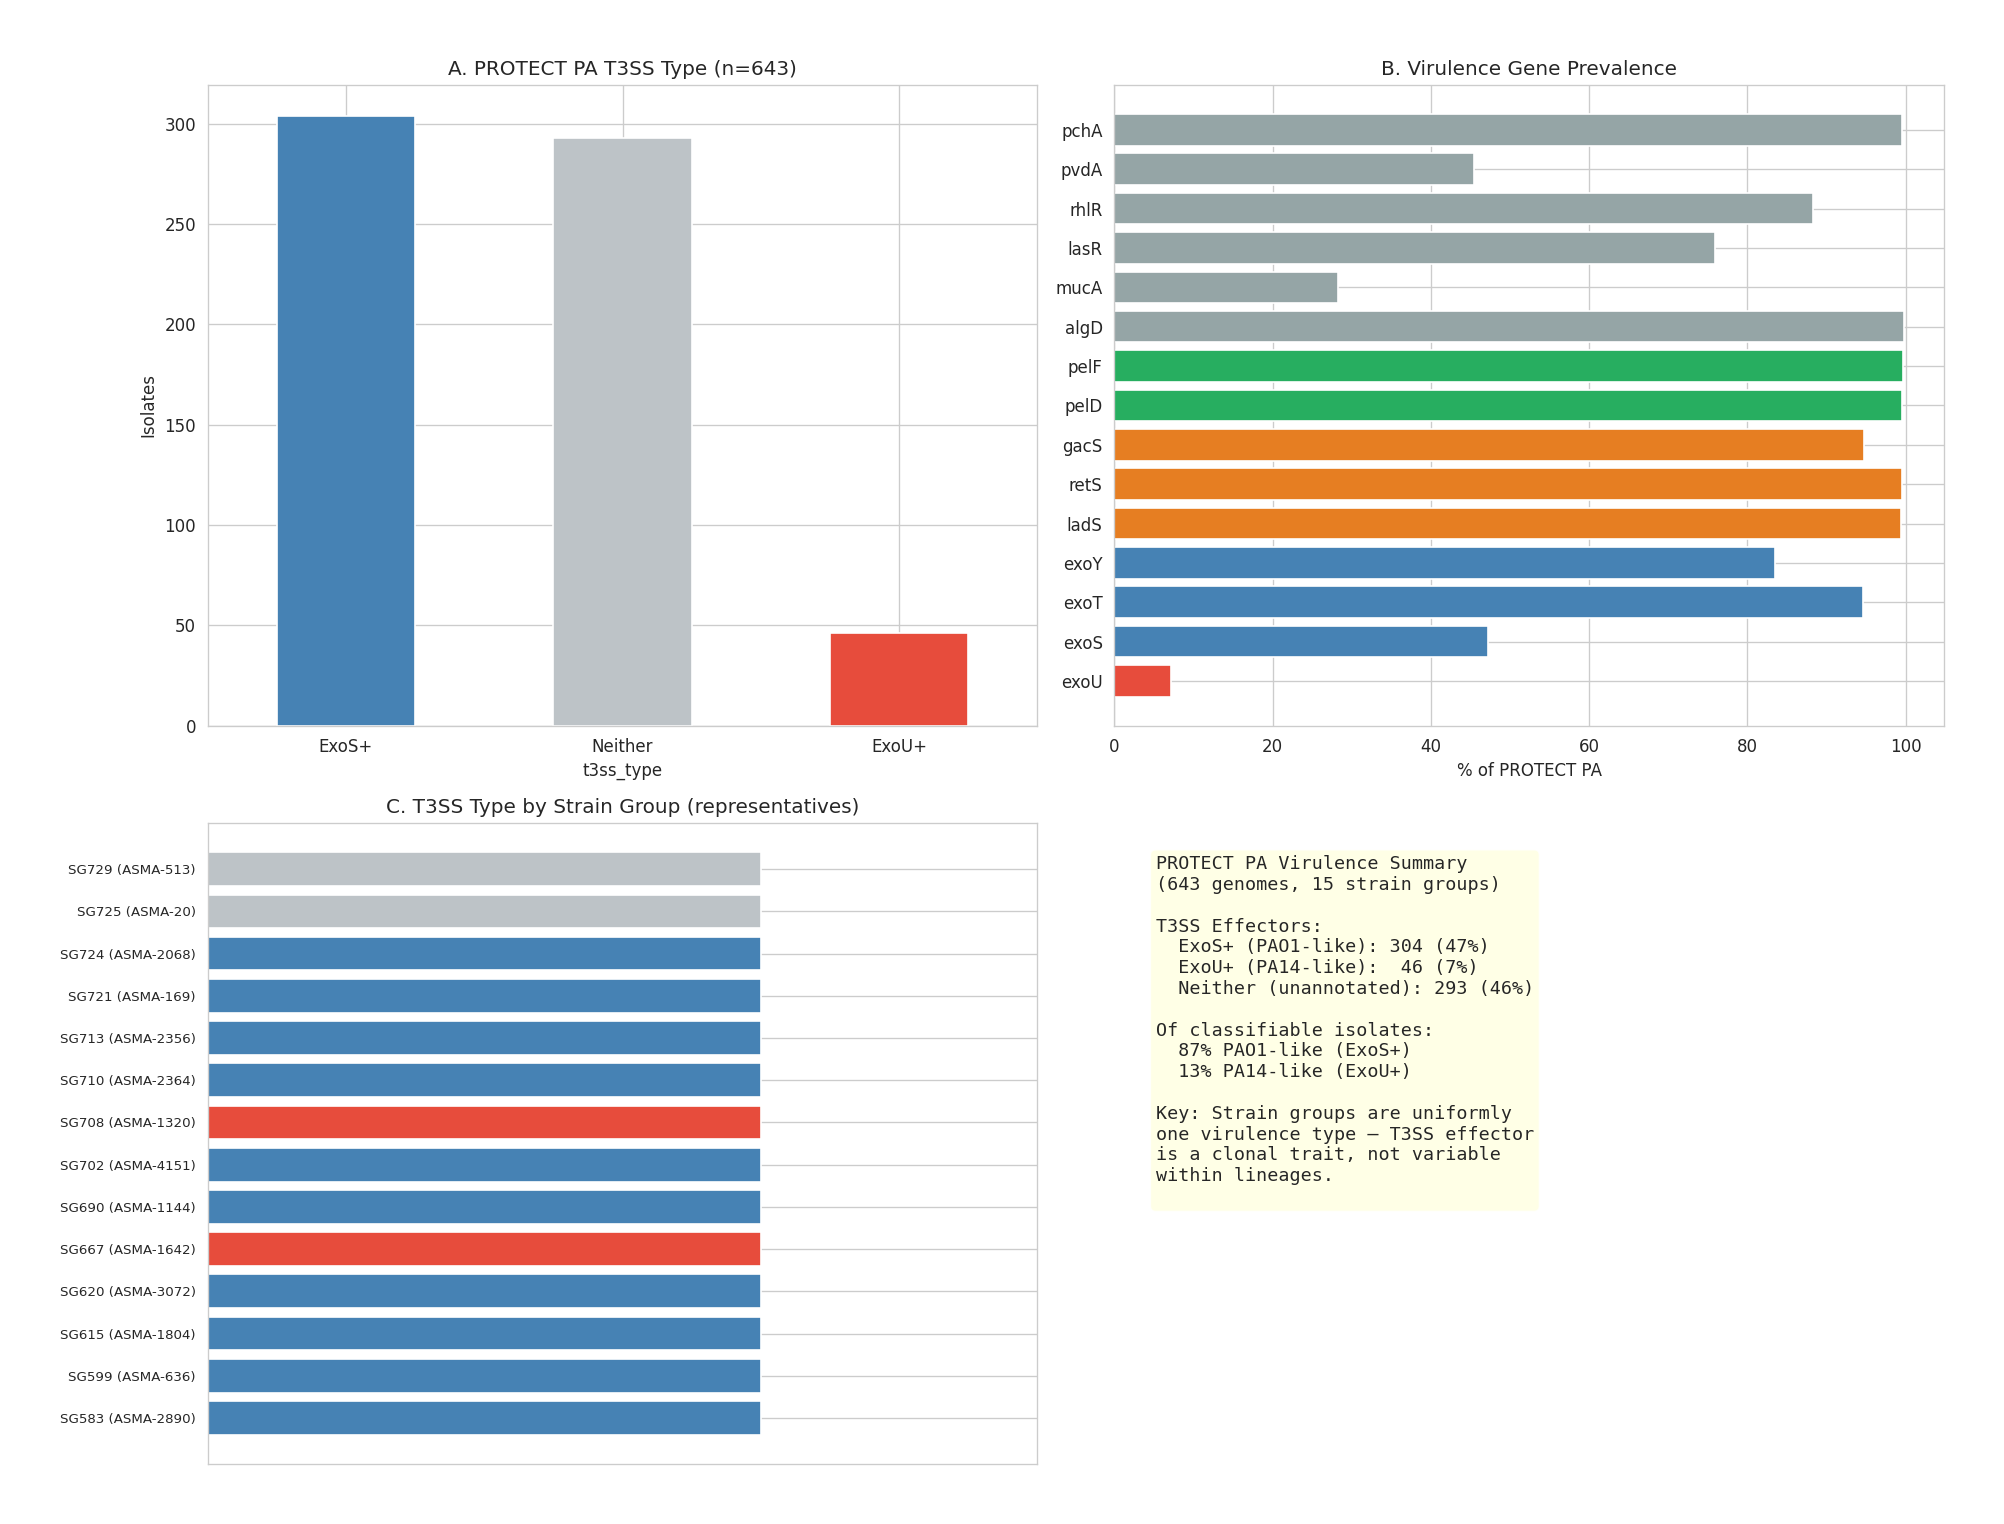

In [10]:
# Summary figure for PROTECT PA
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A: T3SS type
ax = axes[0, 0]
t3ss_cts = vir_pres.t3ss_type.value_counts()
ct = {'ExoS+':'#4682B4','ExoU+':'#E74C3C','ExoU+ExoS+':'#9B59B6','Neither':'#BDC3C7'}
t3ss_cts.plot.bar(ax=ax, color=[ct.get(t,'grey') for t in t3ss_cts.index])
ax.set_ylabel('Isolates'); ax.set_title(f'A. PROTECT PA T3SS Type (n={len(vir_pres)})')
plt.sca(ax); plt.xticks(rotation=0)

# B: Key gene prevalence
ax = axes[0, 1]
key_genes = [g for g in ['exoU','exoS','exoT','exoY','ladS','retS','gacS',
             'pelD','pelF','algD','mucA','lasR','rhlR','pvdA','pchA'] if g in vir_pres.columns]
pcts = [vir_pres[g].sum()/len(vir_pres)*100 for g in key_genes]
clrs = ['#E74C3C' if g=='exoU' else '#4682B4' if 'exo' in g else '#27AE60' if g.startswith(('pel','psl')) else '#E67E22' if g in ['ladS','retS','gacS'] else '#95A5A6' for g in key_genes]
ax.barh(range(len(key_genes)), pcts, color=clrs)
ax.set_yticks(range(len(key_genes))); ax.set_yticklabels(key_genes)
ax.set_xlabel('% of PROTECT PA'); ax.set_title('B. Virulence Gene Prevalence')

# C: T3SS by strain group (reps only)
ax = axes[1, 0]
sg_data = []
for gid in vir_pres.index:
    asma = gid_to_asma.get(gid)
    if asma:
        sg = asma_to_sg.get(asma)
        if sg and gid_to_rep.get(gid) == 'Yes':
            sg_data.append({'strain_group': int(sg), 'asma_id': asma,
                          't3ss': vir_pres.loc[gid, 't3ss_type']})
if sg_data:
    sg_df = pd.DataFrame(sg_data).sort_values('strain_group')
    sg_colors = [ct.get(t, 'grey') for t in sg_df.t3ss]
    ax.barh(range(len(sg_df)), [1]*len(sg_df), color=sg_colors)
    ax.set_yticks(range(len(sg_df)))
    ax.set_yticklabels([f'SG{r.strain_group} ({r.asma_id})' for _, r in sg_df.iterrows()], fontsize=8)
    ax.set_title('C. T3SS Type by Strain Group (representatives)')
    ax.set_xlim(0, 1.5)
    ax.set_xticks([])

# D: Summary text
ax = axes[1, 1]; ax.axis('off')
n_exoS = (vir_pres.t3ss_type == 'ExoS+').sum()
n_exoU = (vir_pres.t3ss_type == 'ExoU+').sum()
n_neither = (vir_pres.t3ss_type == 'Neither').sum()
txt = f"""PROTECT PA Virulence Summary
({len(vir_pres)} genomes, {len(rep_gids)} strain groups)

T3SS Effectors:
  ExoS+ (PAO1-like): {n_exoS} ({n_exoS/len(vir_pres):.0%})
  ExoU+ (PA14-like):  {n_exoU} ({n_exoU/len(vir_pres):.0%})
  Neither (unannotated): {n_neither} ({n_neither/len(vir_pres):.0%})

Of classifiable isolates:
  {n_exoS/(n_exoS+n_exoU)*100:.0f}% PAO1-like (ExoS+)
  {n_exoU/(n_exoS+n_exoU)*100:.0f}% PA14-like (ExoU+)

Key: Strain groups are uniformly
one virulence type — T3SS effector
is a clonal trait, not variable
within lineages.
"""
ax.text(0.05, 0.95, txt, transform=ax.transAxes, fontsize=11, va='top',
        fontfamily='monospace', bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGS / '14_asma_virulence_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary

In [11]:
# Save
annot.to_csv(DATA / 'pa_tree_annotations.tsv', sep='\t')
vir_out = vir_pres[['t3ss_type','biofilm_type','pel_n','psl_n'] +
    [c for c in vir_pres.columns if c in virulence_genes]].copy()
vir_out.to_csv(DATA / 'asma_pa_virulence_profiles.tsv', sep='\t')

print('=' * 70)
print('NB14 SUMMARY')
print('=' * 70)
print(f'\n1. VIRULENCE PROFILES: {len(vir_pres)} PROTECT PA genomes')
print(f'   ExoS+: {n_exoS}, ExoU+: {n_exoU}, Neither: {n_neither}')
print(f'   Of classifiable: {n_exoS/(n_exoS+n_exoU)*100:.0f}% PAO1-like')
print(f'\n2. PFAM TREE: {len(leaf_names)} genomes')
print(f'   PROTECT reps: {annot[annot.identity=="ASMA"].shape[0]}')
print(f'   Pangenome: {annot[annot.identity=="Pangenome"].shape[0]}')
print(f'   References: PAO1 + PA14')
print(f'   Variable Pfam domains: {pfam_variable.shape[1]}')
print(f'\n3. ANNOTATIONS VERIFIED:')
print(f'   T3SS annotated: {(annot.t3ss_type != "Unknown").sum()}/{len(annot)}')
print(f'   Source annotated: {(annot.source != "Unknown").sum()}/{len(annot)}')
print(f'   Labels (ASMA+refs): {(annot.label != "").sum()}')
print(f'\nFiles: pa_pfam_tree.nwk, pa_tree_annotations.tsv, asma_pa_virulence_profiles.tsv')
print(f'Figures: 14_pa_phylogenetic_tree.png, 14_asma_virulence_profiles.png')
import os
for f in ['14_pa_phylogenetic_tree.png','14_asma_virulence_profiles.png']:
    print(f'  {f}: {"OK" if os.path.exists(FIGS / f) else "MISSING"}')

NB14 SUMMARY

1. VIRULENCE PROFILES: 643 PROTECT PA genomes
   ExoS+: 304, ExoU+: 46, Neither: 293
   Of classifiable: 87% PAO1-like

2. PFAM TREE: 165 genomes
   PROTECT reps: 13
   Pangenome: 150
   References: PAO1 + PA14
   Variable Pfam domains: 1557

3. ANNOTATIONS VERIFIED:
   T3SS annotated: 165/165
   Source annotated: 165/165
   Labels (ASMA+refs): 15

Files: pa_pfam_tree.nwk, pa_tree_annotations.tsv, asma_pa_virulence_profiles.tsv
Figures: 14_pa_phylogenetic_tree.png, 14_asma_virulence_profiles.png
  14_pa_phylogenetic_tree.png: OK
  14_asma_virulence_profiles.png: OK
